# Bitcoin Sentiment vs Hyperliquid Trader Performance
Comprehensive EDA and business insights.

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

fg = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

fg['date'] = pd.to_datetime(fg['date'])
trades['trade_date'] = pd.to_datetime(trades['Timestamp IST'], format='mixed', dayfirst=True, errors='coerce').dt.normalize()

df = trades.merge(
    fg[['date','classification','value']],
    left_on='trade_date',
    right_on='date',
    how='left'
)

print("Merged shape:", df.shape)
df.head()


Merged shape: (211224, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,80.0


In [ ]:
import os
files = os.listdir()
print(files)

['.config', 'fear_greed_index.csv', 'historical_data.csv', 'sample_data']


In [ ]:
import os
print( os.listdir())

['.config', 'fear_greed_index.csv', 'historical_data.csv', 'sample_data']


## Dataset Overview

In [ ]:

print(df.info())
print(df.isnull().sum().sort_values(ascending=False).head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  object        
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

## PnL by Sentiment

                count       mean           sum
classification                                
Extreme Greed   39992  67.892861  2.715171e+06
Fear            61837  54.290400  3.357155e+06
Greed           50303  42.743559  2.150129e+06
Extreme Fear    21400  34.537862  7.391102e+05
Neutral         37686  34.307718  1.292921e+06


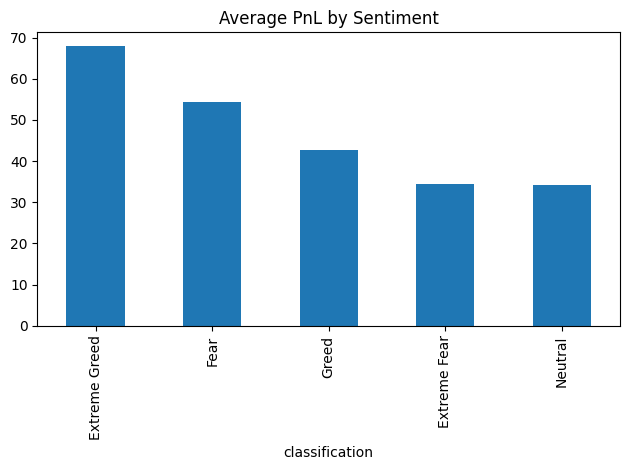

In [ ]:

pnl = df.groupby('classification')['Closed PnL'].agg(['count','mean','sum']).sort_values('mean', ascending=False)
print(pnl)

pnl['mean'].plot(kind='bar', title='Average PnL by Sentiment')
plt.tight_layout()
plt.show()


## Win Rate by Sentiment

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64


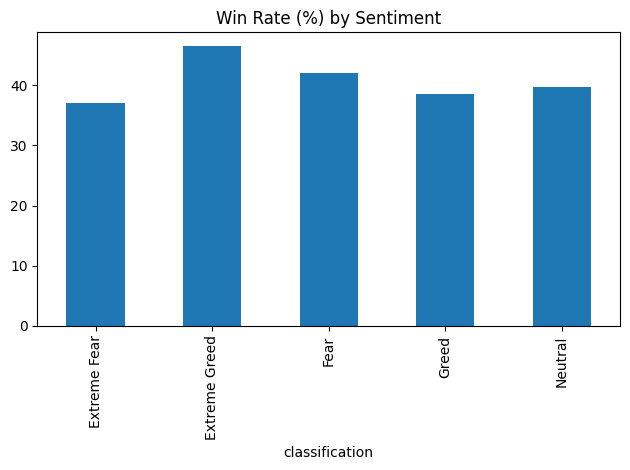

In [ ]:

df['win'] = (df['Closed PnL'] > 0).astype(int)
winrate = df.groupby('classification')['win'].mean()*100
print(winrate)

winrate.plot(kind='bar', title='Win Rate (%) by Sentiment')
plt.tight_layout()
plt.show()


## Trade Volume by Sentiment

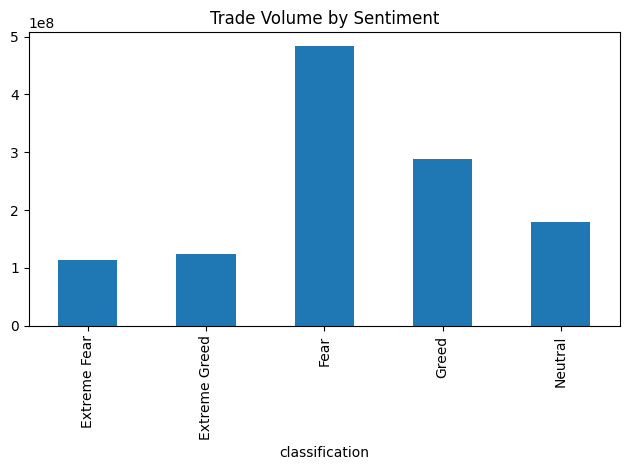

In [ ]:

volume = df.groupby('classification')['Size USD'].sum()
volume.plot(kind='bar', title='Trade Volume by Sentiment')
plt.tight_layout()
plt.show()


## Top Traders

In [ ]:

top_traders = df.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)
print(top_traders)


Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


## Top Coins

In [ ]:

top_coins = df.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=False).head(10)
print(top_coins)


Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64



## Key Insights

1. Extreme Greed tends to produce the highest average profit per trade.
2. Fear periods often generate high total profits because of increased trading activity.
3. Market sentiment appears related to profitability and trading behavior.
4. Win rate and trading activity vary across sentiment regimes.
